## 数值稳定化和模型初始化

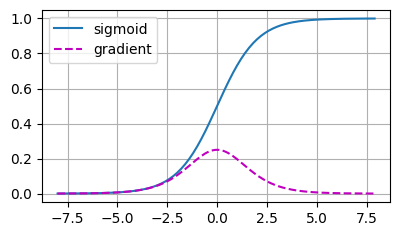

In [1]:
%matplotlib inline
import torch
from torch import nn
from torch.utils import data
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
from IPython import display

def use_svg_display(): 
    """使用svg格式在Jupyter中显示绘图(只在notebook中有效)"""
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):
    """设置matplotlib的图表大小（纯matplotlib版）"""
    plt.rcParams['figure.figsize'] = figsize

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    # 定义刻度类型
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    # 定义显示范围
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    # 显示图例(即左上的线条与线的对应)
    if legend:
        axes.legend(legend)
    axes.grid()

def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点（纯matplotlib版，不依赖d2l）"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    # 检查有无坐标系,没有坐标系就用当前的坐标系
    axes = axes if axes else plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    # 清空坐标系
    axes.cla()
    # fmt是线的样式
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

plot(x.detach().numpy(), [y.detach().numpy(), x.grad.numpy()],
         legend=['sigmoid', 'gradient'], figsize=(4.5, 2.5))

In [2]:
M = torch.normal(0, 1, size=(4,4))
print('一个矩阵 \n',M)
for i in range(100):
    M = torch.mm(M,torch.normal(0, 1, size=(4, 4)))

print('乘以100个矩阵后\n', M)

一个矩阵 
 tensor([[-0.0494, -0.3396,  0.2883, -0.4458],
        [-0.6820,  0.0708, -0.5183,  0.5358],
        [-0.3315,  1.2585,  0.6901, -0.9126],
        [ 1.0370, -0.4013, -2.0112,  1.0573]])
乘以100个矩阵后
 tensor([[ 3.9029e+25, -9.8837e+24, -4.9378e+25, -1.2165e+25],
        [-1.4294e+25,  3.6197e+24,  1.8084e+25,  4.4553e+24],
        [ 9.4359e+23, -2.3894e+23, -1.1938e+24, -2.9412e+23],
        [-3.2484e+25,  8.2262e+24,  4.1097e+25,  1.0125e+25]])


xavier初始化是针对sigmod和tanh提出的,对relu家族无效
> relu可以看看He初始化